[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch13_workbook.ipynb)

# Majority vote over reasoning chains

Self-consistency samples several reasoning chains for one question and
returns the answer that most of them reach. When each question has a right
answer and a wrong one and the chains err independently, the vote of many
chains approaches the right answer if one chain is right more often than
wrong, and the wrong answer if one chain is wrong more often than right.

In [1]:
#@title Setup: run this cell first
import functools
import math

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

#% comb(1000, 500) is 2.7e299 and fits in a 64-bit float; comb(1030, 515)
#% does not, so K stops at 1,000.
K_MAX, SHARED, P_APP, TARGET, SEARCH, RHOS = 1000, 0.5, 0.6, 0.75, 201, (0, 0.2, 0.5, 0.8, 1)


# A setting a cell refuses: Colab prints the one sentence, without the stack.
class Refused(Exception):
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


# Refuse a setting with one sentence. An int of more than 4,300 digits has no repr, so an
# int above 1e40 is named by its size.
def need(ok, name, value, rule):
    s = repr(value) if type(value) is not int or abs(value) < 1e40 else "an int above 1e40"
    if not ok:
        raise Refused(f"{name} is {s[:40]}{'…' if len(s) > 40 else ''}: {rule}.")
    return value


def whole(k):
    rule = "it must be a whole number from 1 to 1,000"
    return need(type(k) is int and 1 <= k <= K_MAX, "K", k, rule)


def share(x, name):
    need(type(x) in (int, float) and 0 <= x <= 1, name, x, "it must be a number from 0 to 1")
    return float(x)


def switch(x):
    return need(type(x) is bool, "CORRELATED", x, "it must be True or False")


# A probability to three decimals, or a bound where three decimals would show 0 or 1. A float
# that underflowed to 0 or rounded to 1 then reads as a bound, which is true of it.
def pr(x):
    bound = "below 0.0005" if x < 0.0005 else "above 0.9995"
    return f"{x:.3f}" if 0.0005 <= x <= 0.9995 else bound


# How a vote's accuracy compares with one chain's, d being their difference.
def than(d):
    return "more often than" if d > 1e-12 else "less often than" if d < -1e-12 else "as often as"


# P(i of k independent chains are right), i = 0 to k, each right with probability p.
@functools.lru_cache(maxsize=None)
def counts(k, p):
    return np.array([math.comb(k, i) * p ** i * (1 - p) ** (k - i) for i in range(k + 1)])


# The same when, with probability rho, all k chains copy one outcome.
def shared(k, p, rho):
    q = (1 - rho) * counts(k, p)
    q[[0, k]] += (rho * (1 - p), rho * p)
    return q


# P(the vote is right): more than half the chains right, plus half of a tie at an even k, which
# a fair coin breaks. tie=0 scores a tie wrong, as the lecture's K = 40 figure does.
def vote(q, tie=0.5):
    i, k = np.arange(len(q)), len(q) - 1
    return q[2 * i > k].sum() + tie * q[2 * i == k].sum()


# At an even k: each distribution's tie, and its vote when a tie is scored wrong.
def tied(*runs):
    m = (len(runs[0][0]) - 1) // 2
    t = " and ".join(f"{pr(q[m])}{name}" for q, name in runs)
    w = " and ".join(f"{pr(vote(q, 0))}{name}" for q, name in runs)
    return "" if len(runs[0][0]) % 2 == 0 else (
        f" A split of {m:,} to {m:,} is a tie, probability {t}, which the coin makes half "
        f"right; scored wrong, as the lecture's K = 40 figure does, a tie leaves the vote right "
        f"with probability {w}.")


# Bars of P(i chains right) by the vote's outcome; beside them, accuracy as bars.
def chart(k, p, rho=0.0):
    q, i = shared(k, p, rho), np.arange(k + 1)
    fig, (ax, bx) = plt.subplots(1, 2, figsize=(6, 3.5), gridspec_kw={"width_ratios": (5, 4)})
    #% Greyscale luma: blue 0.39, orange 0.60, silver 0.75, the one-chain grey 0.20 and the
    #% independent vote's white 1.00, each 0.15 or more from every other (review R5, R8).
    kinds = ((2 * i > k, "majority right", "tab:blue", "//", "-", "o"),
             (2 * i < k, "majority wrong", "silver", "", ":", "s"),
             (2 * i == k, "tie, half right by a coin", "tab:orange", "xx", "--", "D"))
    #% Above 60 a bar is under a pixel wide and drew none at K = 300 and 1,000 (review R4):
    #% stems, each kind in its own line style, and a marker on the ends and the tie.
    ends = [0, k] if k % 2 else [0, k // 2, k]
    for m, label, colour, hatch, style, mark in kinds:
        if m.any() and k <= 60:
            ax.bar(i[m], q[m], width=0.8, color=colour, hatch=hatch, edgecolor="white",
                   linewidth=0, label=label)
        elif m.any():
            ax.vlines(i[m], 0, q[m], colors=colour, linestyles=style, lw=1.5, label=label)
            ax.plot([j for j in ends if m[j]], q[[j for j in ends if m[j]]], mark, color=colour,
                    mec="black", mew=0.6, ms=5, zorder=3)
    #% The top sixth of the axes, 30 points, holds no bar, so the two lines written there, 22
    #% points, sit on nothing; on one line "below 0.0005" twice ran into the right panel.
    ax.text(0.02, 0.97, f"all wrong: {pr(q[0])}\nall right: {pr(q[k])}", transform=ax.transAxes,
            va="top", fontsize=8)
    ax.set(xlabel=f"chains right, of {k:,}", ylabel="probability", ylim=(0, 1.2 * q.max()),
           yticks=plt.MaxNLocator(5, steps=[1, 2, 5, 10]).tick_values(0, q.max()))
    ax.xaxis.set_major_locator(plt.MaxNLocator(7, integer=True))
    fig.legend(fontsize=8, ncol=3, loc="upper left", bbox_to_anchor=(0.01, 1), frameon=False)
    bars = [("one\nchain", p, "0.2", "", "white")]
    if rho:
        bars.append(("vote,\nindependent", vote(counts(k, p)), "white", "\\\\", "tab:blue"))
    bars.append(("vote,\nshared" if rho else "vote", vote(q), "tab:blue", "//", "white"))
    for x, (name, v, colour, hatch, edge) in enumerate(bars):
        b = bx.bar(x, v, color=colour, hatch=hatch, edgecolor=edge, linewidth=0.8)
        bx.bar_label(b, labels=[pr(v)], fontsize=8)
    bx.set_xticks(range(len(bars)), labels=[b[0] for b in bars], fontsize=8)
    bx.set(ylabel="probability the answer is right", ylim=(0, 1.15), yticks=np.linspace(0, 1, 6))
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()


display(Markdown("Each question has a right answer and a wrong one. The vote of K chains returns "
                 "the answer more than half of them give; at an even K a fair coin breaks a tie."))

Each question has a right answer and a wrong one. The vote of K chains returns the answer more than half of them give; at an even K a fair coin breaks a tie.

## 1. The vote of chains that are right more often than wrong

Each of `K` chains answers a question right with probability 0.6,
independently of the others, and the vote is right when more than half of
them are. At an even `K` a fair coin breaks a tie and counts as half a right
answer, so an even `K` is exactly as accurate as the odd `K` below it. Run
the cell, then set `K` to 15 and run it again: how often is the vote right at
each setting, and how often is one chain?

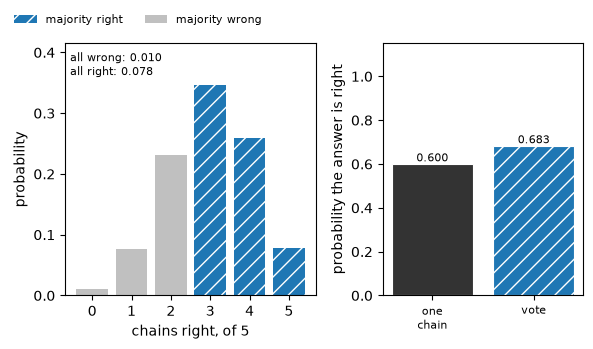

In [2]:
K = 5
chart(whole(K), 0.6)

### Solution

In [3]:
k = whole(K)
q, nxt = counts(k, 0.6), vote(counts(k + 2, 0.6))
buy = f"{100 * (nxt - vote(q)):.2f}" if nxt - vote(q) >= 0.0001 else "less than 0.01"
display(Markdown(f"At K = {k:,} the vote is right with probability {pr(vote(q))}, "
                 f"{than(vote(q) - 0.6)} one chain, which is right with probability 0.600."
                 f"{tied((q, ''))} With K + 2 chains it is right with probability {pr(nxt)}: "
                 f"the two more calls buy {buy} percentage points. At K = 15 the vote is right "
                 f"with probability {pr(vote(counts(15, 0.6)))}."))

At K = 5 the vote is right with probability 0.683, more often than one chain, which is right with probability 0.600. With K + 2 chains it is right with probability 0.710: the two more calls buy 2.76 percentage points. At K = 15 the vote is right with probability 0.787.

## 2. The vote of chains that are wrong more often than right

Each chain is right with probability `P`, set below one half, and every
question has a right answer and a wrong one. Run the cell, then set `K`
to 15 and to 41: is the vote right more or less often than one chain, and
what does adding chains do to it?

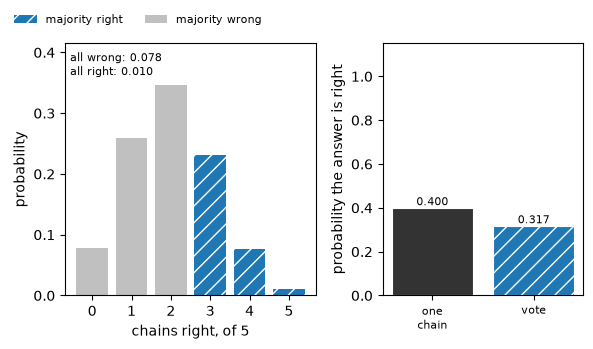

In [4]:
P = 0.4
K = 5
chart(whole(K), share(P, "P"))

### Solution

In [5]:
k, p = whole(K), share(P, "P")
acc, r = vote(counts(k, p)), [vote(counts(n, p)) for n in (1, 5, 15, 41)]
trend = (f"is {pr(r[0])} at each" if pr(r[0]) == pr(r[-1]) else
         f"{'falls' if r[-1] < r[0] else 'rises'} from {pr(r[0])} to {pr(r[-1])}")
display(Markdown(f"At p = {p:g} and K = {k:,} the vote is right with probability {pr(acc)}, "
                 f"{than(acc - p)} one chain.{tied((counts(k, p), ''))} Over 1, 5, 15 and 41 "
                 f"chains, odd numbers that never tie, it {trend}: {', '.join(map(pr, r))}."))

At p = 0.4 and K = 5 the vote is right with probability 0.317, less often than one chain. Over 1, 5, 15 and 41 chains, odd numbers that never tie, it falls from 0.400 to 0.097: 0.400, 0.317, 0.213, 0.097.

## 3. Chains that share one outcome

With probability 0.5 all `K` chains copy one shared outcome, right with
probability 0.6, and otherwise they answer independently. Run the cell, then
run it again with `CORRELATED = False`: how often is the vote right, and how
often are all the chains wrong together, at each setting?

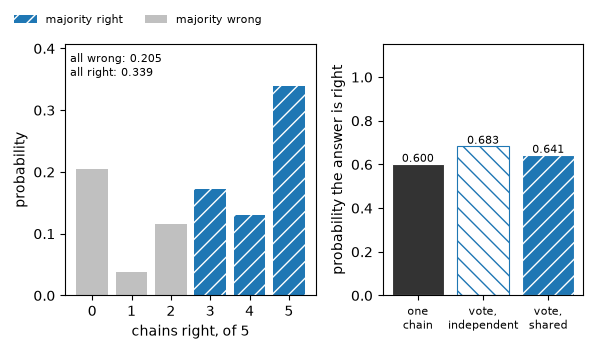

In [6]:
CORRELATED = True
K = 5
chart(whole(K), 0.6, SHARED if switch(CORRELATED) else 0)

### Solution

In [7]:
k, on = whole(K), switch(CORRELATED)
ind, cor = counts(k, 0.6), shared(k, 0.6, SHARED)
d0, d1 = vote(ind) - 0.6, vote(cor) - 0.6
more = "raises" if cor[0] - ind[0] > 1e-12 else "does not change"
gap = (f" The vote's distance from one chain shrinks from {d0:+.3f} to {d1:+.3f}, {d1 / d0:.2f} "
       f"of it: the shared outcome is one chain's answer copied {k:,} times." if abs(d0) > 1e-12
       else " The vote is right as often as one chain, shared or not.")
display(Markdown(f"At K = {k:,} the vote is right with probability {pr(vote(ind))} with "
                 f"independent chains and {pr(vote(cor))} when they copy one shared outcome with "
                 f"probability {SHARED}. Sharing {more} the chance that every chain is wrong: "
                 f"{pr(ind[0])} independent, {pr(cor[0])} shared.{gap}"
                 f"{tied((ind, ' independent'), (cor, ' shared'))}"))

At K = 5 the vote is right with probability 0.683 with independent chains and 0.641 when they copy one shared outcome with probability 0.5. Sharing raises the chance that every chain is wrong: 0.010 independent, 0.205 shared. The vote's distance from one chain shrinks from +0.083 to +0.041, 0.50 of it: the shared outcome is one chain's answer copied 5 times.

## Appendix. A shared outcome puts a ceiling on the vote

K chains answer a question that has a right answer and a wrong one, each
right with probability p. When they answer independently, the number X of
right chains is binomial,

P(X = i) = C(K, i) · pⁱ · (1 − p)^(K − i),  i = 0, 1, …, K,

and the vote is right when more than half the chains are. At an even K a
split of K/2 to K/2 is a tie, which a fair coin breaks:

A(K) = Σ over i > K/2 of P(X = i), plus P(X = K/2) / 2 at an even K.

With the coin an even K is exactly as accurate as the odd K − 1 below it.
Between odd values,

A(K + 2) − A(K) = C(K, (K + 1)/2) · (p(1 − p))^((K + 1)/2) · (2p − 1),

whose sign is the sign of 2p − 1: as K grows the vote rises towards 1 when
p > 1/2 and falls towards 0 when p < 1/2, the Condorcet jury theorem.

A shared outcome: with probability ρ, from 0 to 1, all K chains copy one
outcome, right with probability p, and otherwise they answer independently.
One chain is then right with probability p at every ρ, two chains'
right-or-wrong outcomes have correlation ρ, and

A_ρ(K) = ρ · p + (1 − ρ) · A(K).

At ρ = 0 this is A(K); at ρ = 1 it is p for every K. For p > 1/2 it
approaches 1 − ρ(1 − p) as K grows, and no K passes that ceiling. In a
second model the shared outcome is always wrong: one chain is then right with
probability (1 − ρ)p, and the ceiling is 1 − ρ. Each chain is one model call,
so two more chains cost two more calls, and in the first model they buy

A_ρ(K + 2) − A_ρ(K) = (1 − ρ) · (A(K + 2) − A(K))

of accuracy. At p = 0.6, for odd K from 1 to 41:

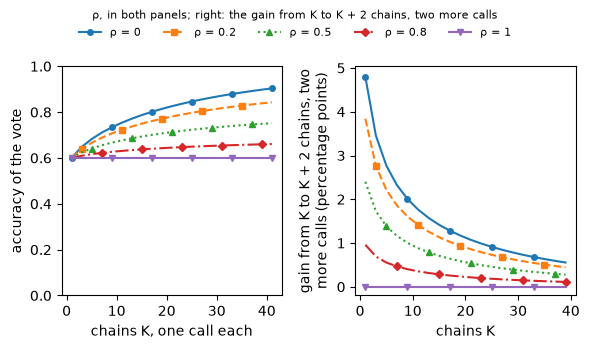

In [8]:
ks = np.arange(1, 42, 2)
acc = {r: np.array([vote(shared(k, P_APP, r)) for k in ks]) for r in RHOS}
fig, (ax, bx) = plt.subplots(1, 2, figsize=(6, 3.5))
for i, ((r, a), st) in enumerate(zip(acc.items(), ("-o", "--s", ":^", "-.D", "-v"))):
    ax.plot(ks, a, st, markevery=(i % 4, 4), ms=4, label=f"ρ = {r:g}")
    bx.plot(ks[:-1], 100 * np.diff(a), st, markevery=(i % 4, 4), ms=4)
ax.set(xlabel="chains K, one call each", ylabel="accuracy of the vote", ylim=(0, 1))
bx.set(xlabel="chains K", ylim=(-0.2, None),
       ylabel="gain from K to K + 2 chains, two\nmore calls (percentage points)")
fig.legend(loc="upper center", ncol=5, fontsize=8, frameon=False, title_fontsize=8,
           title="ρ, in both panels; right: the gain from K to K + 2 chains, two more calls")
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

**Exercise.** Set `RHO` to 0, 0.2, 0.5, 0.8 and 1 in turn and rerun the
cell. How many chains does the vote need to be right with probability 0.75,
and what accuracy does it approach as K grows?

In [9]:
RHO = 0.5

r = share(RHO, "RHO")
hit = next((k for k in range(1, SEARCH + 1, 2) if vote(shared(k, P_APP, r)) >= TARGET), None)
reach = (f"{hit} chains are the fewest" if hit else "no number of chains is enough"
         if 1 - r * (1 - P_APP) <= TARGET else f"no odd number of chains up to {SEARCH} is enough")
print(f"ρ = {r:g}: the vote of 5 chains is right with probability {vote(shared(5, P_APP, r)):.3f} "
      f"and of 41 with {vote(shared(41, P_APP, r)):.3f}; it approaches 1 − ρ(1 − p) = "
      f"{1 - r * (1 - P_APP):.4f}, and {reach} to reach {TARGET}.")

ρ = 0.5: the vote of 5 chains is right with probability 0.641 and of 41 with 0.752; it approaches 1 − ρ(1 − p) = 0.8000, and 41 chains are the fewest to reach 0.75.


### Solution

In [10]:
odd = range(1, SEARCH + 1, 2)
a = {r: {k: vote(shared(k, P_APP, r)) for k in odd} for r in RHOS}
hit = {r: next((k for k in odd if a[r][k] >= TARGET), None) for r in RHOS}
buy = {r: 100 * (a[r][41] - a[r][39]) for r in RHOS}
never = " and ".join(f"{r:g}" for r in RHOS if hit[r] is None and 1 - r * (1 - P_APP) <= TARGET)
rows = "".join(f"\n| {r:g} | {a[r][5]:.3f} | {a[r][41]:.3f} | {1 - r * (1 - P_APP):.3f} | "
               f"{hit[r] or 'none'} | {buy[r]:.3f} |" for r in RHOS)
display(Markdown(
    "| ρ | vote of 5 | vote of 41 | limit 1 − ρ(1 − p) | fewest chains to reach 0.75 | points "
    "gained from 39 to 41 chains |\n| ---: | ---: | ---: | ---: | ---: | ---: |" + rows + "\n\n"
    f"At p = {P_APP} the vote reaches {TARGET} with "
    + ", ".join(f"{hit[r]} chains at ρ = {r:g}" for r in RHOS if hit[r]) + ". "
    + (f"At ρ = {never} the limit is {TARGET} or less, and no number of chains reaches it. "
       if never else "")
    + f"From 39 to 41 chains, two more calls buy {buy[0]:.3f} percentage points at ρ = 0 and "
    f"{buy[0.5]:.3f} at ρ = 0.5, {buy[0.5] / buy[0]:.2f} times as much."))

| ρ | vote of 5 | vote of 41 | limit 1 − ρ(1 − p) | fewest chains to reach 0.75 | points gained from 39 to 41 chains |
| ---: | ---: | ---: | ---: | ---: | ---: |
| 0 | 0.683 | 0.903 | 1.000 | 11 | 0.554 |
| 0.2 | 0.666 | 0.843 | 0.920 | 17 | 0.443 |
| 0.5 | 0.641 | 0.752 | 0.800 | 41 | 0.277 |
| 0.8 | 0.617 | 0.661 | 0.680 | none | 0.111 |
| 1 | 0.600 | 0.600 | 0.600 | none | 0.000 |

At p = 0.6 the vote reaches 0.75 with 11 chains at ρ = 0, 17 chains at ρ = 0.2, 41 chains at ρ = 0.5. At ρ = 0.8 and 1 the limit is 0.75 or less, and no number of chains reaches it. From 39 to 41 chains, two more calls buy 0.554 percentage points at ρ = 0 and 0.277 at ρ = 0.5, 0.50 times as much.